In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.columns = df.columns.str.replace(r'[\n\r"]', '', regex=True).str.strip()

In [4]:
df = df.rename(columns={
    'ZIP Code': 'ZIP',
    '備註 / 城市 / 區域': 'Note',
    'Median Income': 'Income',
    'Population': 'Population',
    'Land Area (sq mi)': 'LandArea',
    'Population Density (people per square mile)': 'Density',
    'Education Level Rate(Bachelor\'s degreeor higher)': 'Education',
    'Housing Median Prices(Dollars)': 'Housing',
    'Unemployment Rate': 'Unemployment',
    'Crime Rate(/1,000)': 'CrimeRate'
})

In [5]:
numeric_cols = ['Income','Population','LandArea','Density','Education',
                'Housing','Unemployment','CrimeRate']

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
        .str.replace('%', '')
        .str.replace('$', '')
        .str.strip()
    )

df['Education'] = df['Education'].astype(float) / 100
df['Unemployment'] = df['Unemployment'].astype(float) / 100

for col in ['Income','Population','LandArea','Density','Housing','CrimeRate']:
    df[col] = df[col].astype(float)

In [6]:
def minmax(series, invert=False):
    scaled = (series - series.min()) / (series.max() - series.min())
    return 1 - scaled if invert else scaled

df['CrimeScore'] = minmax(df['CrimeRate'], invert=True)
df['IncomeScore'] = minmax(df['Income'])
df['EduScore'] = minmax(df['Education'])
df['HousingScore'] = minmax(df['Housing'])
df['UnempScore'] = minmax(df['Unemployment'], invert=True)
df['DensityScore'] = minmax(df['Density'])

In [7]:
df['FinalScore'] = (
    0.30 * df['CrimeScore'] +
    0.20 * df['IncomeScore'] +
    0.20 * df['EduScore'] +
    0.10 * df['HousingScore'] +
    0.10 * df['UnempScore'] +
    0.10 * df['DensityScore']
)

df['FinalScore'] = df['FinalScore'] * 100

In [8]:
result = df[['ZIP', 'FinalScore', 'CrimeScore', 'IncomeScore',
             'EduScore','HousingScore','UnempScore','DensityScore']].sort_values(by="FinalScore", ascending=False)

print(result)

      ZIP  FinalScore  CrimeScore  IncomeScore  EduScore  HousingScore  \
11  22125   83.206349    0.955857     0.753997  1.000000      0.315461   
7   20169   77.191796    0.713073     1.000000  0.979167      0.559221   
4   20136   71.739704    0.872666     0.844889  0.752976      0.443199   
3   20112   69.687043    0.809847     0.944696  0.672619      0.481661   
6   20155   65.805674    0.730051     0.664094  0.750000      0.500382   
8   20181   65.739225    0.972835     0.728957  0.443452      0.552598   
5   20143   64.237302    0.726655     0.845096  0.276786      1.000000   
9   22025   59.121715    0.728353     0.521603  0.752976      0.331381   
15  22192   53.834753    0.709677     0.414570  0.571429      0.290372   
12  22134   52.182930    1.000000     0.000000  0.699405      0.000000   
13  22172   47.561117    0.952462     0.345817  0.333333      0.346536   
14  22191   45.376732    0.599321     0.307076  0.252976      0.248472   
10  22026   45.255231    0.718166     

In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
zip_shapes = gpd.read_file("zip_shapes.geojson")
scores = pd.read_csv("ZIP_Final_Scores.csv")

In [16]:
zip_shapes["ZipCode"] = zip_shapes["ZipCode"].astype(str).str.zfill(5)
scores["ZIP"] = scores["ZIP"].astype(str).str.zfill(5)

In [17]:
zip_shapes = zip_shapes.rename(columns={"ZipCode": "ZIP"})
merged = zip_shapes.merge(scores, on="ZIP", how="left")

In [23]:
scores = scores.sort_values("FinalScore", ascending=False)
scores["Rank"] = range(1, len(scores) + 1)
scores["ZIP"] = scores["ZIP"].astype(str).str.zfill(5)
print(scores)

      ZIP  FinalScore  CrimeScore  IncomeScore  EduScore  HousingScore  \
0   22125   83.206349    0.955857     0.753997  1.000000      0.315461   
1   20169   77.191796    0.713073     1.000000  0.979167      0.559221   
2   20136   71.739704    0.872666     0.844889  0.752976      0.443199   
3   20112   69.687043    0.809847     0.944696  0.672619      0.481661   
4   20155   65.805674    0.730051     0.664094  0.750000      0.500382   
5   20181   65.739225    0.972835     0.728957  0.443452      0.552598   
6   20143   64.237302    0.726655     0.845096  0.276786      1.000000   
7   22025   59.121715    0.728353     0.521603  0.752976      0.331381   
8   22192   53.834753    0.709677     0.414570  0.571429      0.290372   
9   22134   52.182930    1.000000     0.000000  0.699405      0.000000   
10  22172   47.561117    0.952462     0.345817  0.333333      0.346536   
11  22191   45.376732    0.599321     0.307076  0.252976      0.248472   
12  22026   45.255231    0.718166     

<Figure size 1200x800 with 0 Axes>

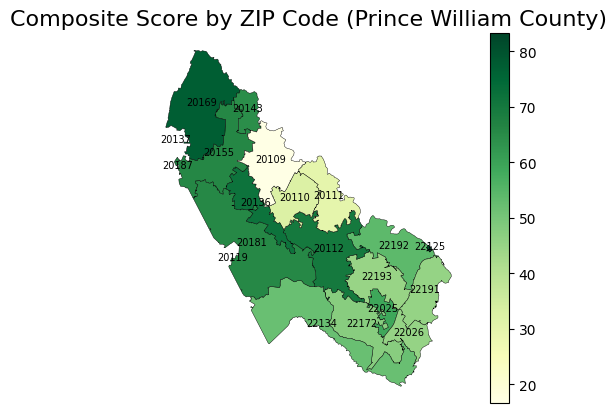

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
merged.plot(
    column="FinalScore",
    cmap="YlGn",
    legend=True,
    edgecolor="black",
    linewidth=0.3
)

# 加上 ZIP Code 標籤
for idx, row in merged.iterrows():
    if row["geometry"] is not None:
        x = row["geometry"].centroid.x
        y = row["geometry"].centroid.y
        plt.text(x, y, row["ZIP"], fontsize=7, ha="center")

plt.title("Composite Score by ZIP Code (Prince William County)", fontsize=16)
plt.axis("off")
plt.show()


<Figure size 1200x600 with 0 Axes>

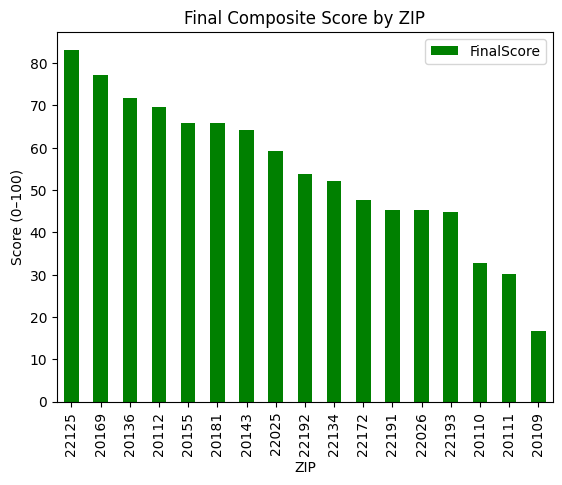

In [34]:
plt.figure(figsize=(12,6))
scores.sort_values("FinalScore", ascending=False).plot(
    x="ZIP",
    y="FinalScore",
    kind="bar",
    color="green"
)
plt.title("Final Composite Score by ZIP")
plt.ylabel("Score (0–100)")
plt.show()


<Figure size 1200x600 with 0 Axes>

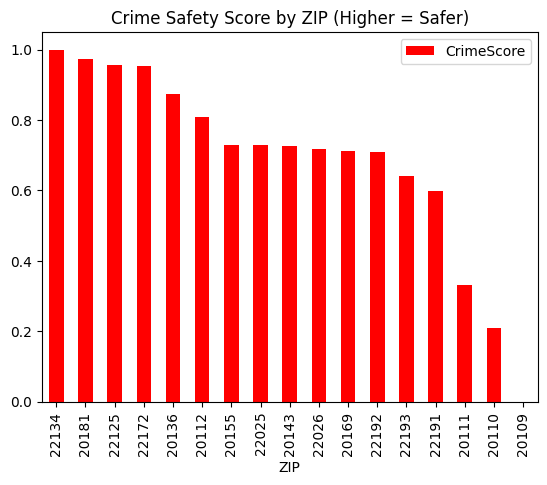

In [35]:
plt.figure(figsize=(12,6))
scores.sort_values("CrimeScore", ascending=False).plot(
    x="ZIP",
    y="CrimeScore",
    kind="bar",
    color="red"
)
plt.title("Crime Safety Score by ZIP (Higher = Safer)")
plt.show()


<Figure size 1200x600 with 0 Axes>

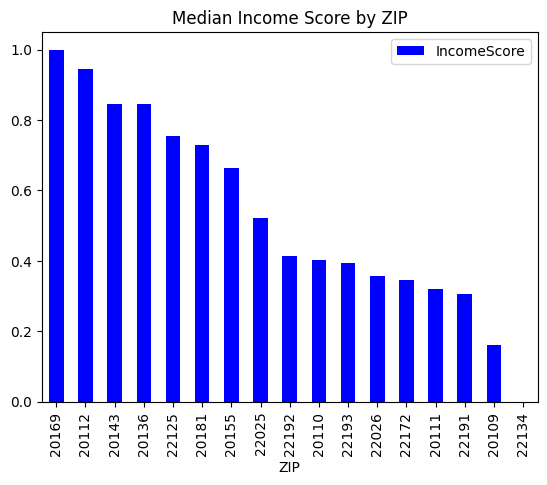

In [36]:
plt.figure(figsize=(12,6))
scores.sort_values("IncomeScore", ascending=False).plot(
    x="ZIP",
    y="IncomeScore",
    kind="bar",
    color="blue"
)
plt.title("Median Income Score by ZIP")
plt.show()


<Figure size 1200x600 with 0 Axes>

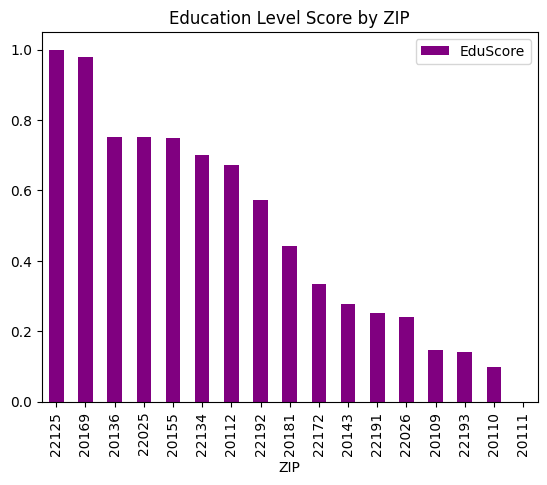

In [37]:
plt.figure(figsize=(12,6))
scores.sort_values("EduScore", ascending=False).plot(
    x="ZIP",
    y="EduScore",
    kind="bar",
    color="purple"
)
plt.title("Education Level Score by ZIP")
plt.show()


<Figure size 1200x600 with 0 Axes>

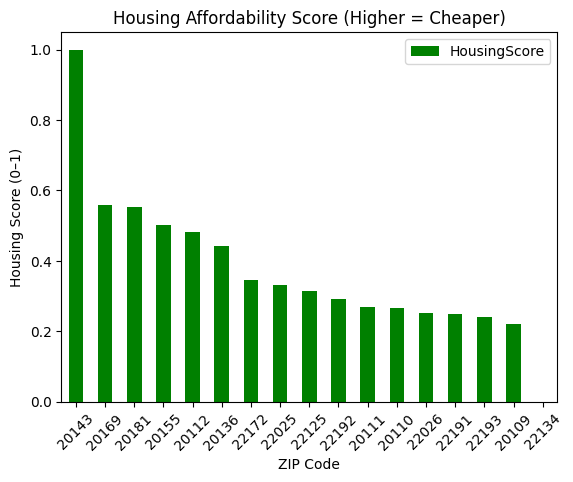

In [39]:
plt.figure(figsize=(12,6))
scores.sort_values("HousingScore", ascending=False).plot(
    x="ZIP", y="HousingScore", kind="bar", color="green"
)

plt.title("Housing Affordability Score (Higher = Cheaper)")
plt.ylabel("Housing Score (0–1)")
plt.xlabel("ZIP Code")
plt.xticks(rotation=45)
plt.show()


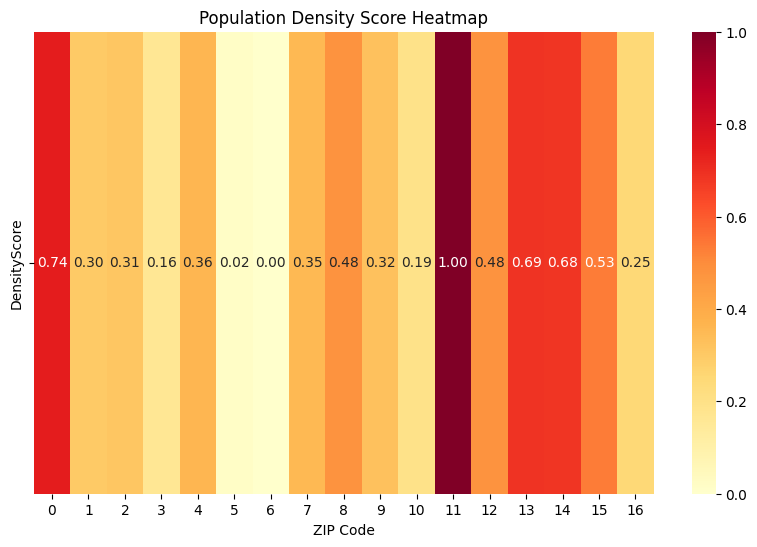

In [40]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(
    scores[["DensityScore"]].T,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    cbar=True
)

plt.title("Population Density Score Heatmap")
plt.xlabel("ZIP Code")
plt.show()


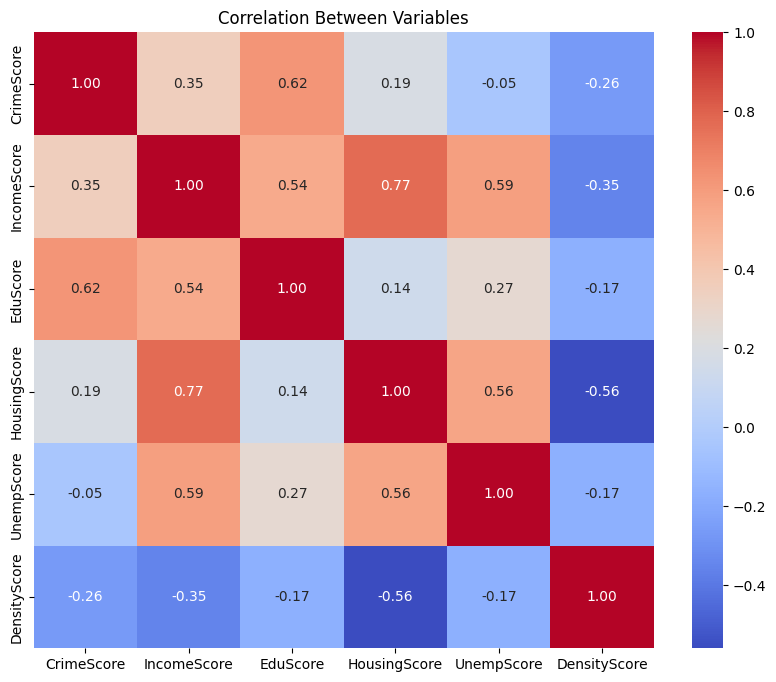

In [41]:
plt.figure(figsize=(10,8))
sns.heatmap(
    scores[["CrimeScore","IncomeScore","EduScore","HousingScore","UnempScore","DensityScore"]].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Variables")
plt.show()


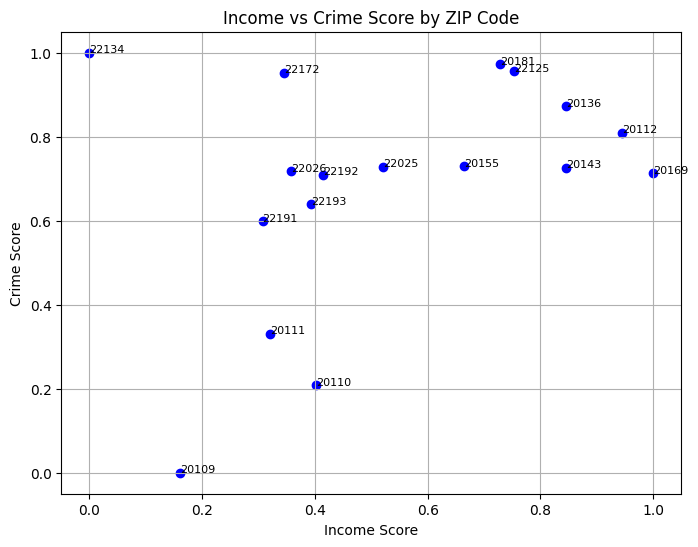

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(scores["IncomeScore"], scores["CrimeScore"], color="blue")

for i, row in scores.iterrows():
    plt.text(row["IncomeScore"], row["CrimeScore"], row["ZIP"], fontsize=8)

plt.title("Income vs Crime Score by ZIP Code")
plt.xlabel("Income Score")
plt.ylabel("Crime Score")
plt.grid(True)
plt.show()


In [43]:
import plotly.express as px

fig = px.scatter(
    scores,
    x="IncomeScore",
    y="CrimeScore",
    color="FinalScore",
    text="ZIP",
    color_continuous_scale="Viridis",
    title="Interactive Income vs Crime Scatter (ZIP Labelled)"
)

fig.update_traces(textposition="top center")
fig.show()


In [54]:
import plotly.express as px
import plotly.graph_objects as go

table = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=[
                    "ZIP","Rank","FinalScore",
                    "CrimeScore","IncomeScore","EduScore",
                    "HousingScore","UnempScore","DensityScore"
                ],
                fill_color="black",
                font=dict(color="white", size=12),
                align="center"
            ),
            cells=dict(
                values=[
                    scores["ZIP"],
                    scores["Rank"],
                    scores["FinalScore"].round(2),
                    scores["CrimeScore"].round(3),
                    scores["IncomeScore"].round(3),
                    scores["EduScore"].round(3),
                    scores["HousingScore"].round(3),
                    scores["UnempScore"].round(3),
                    scores["DensityScore"].round(3)
                ],
                fill_color="white",
                align="center",
                font=dict(color="black", size=11)
            )
        )
    ]
)


table.update_layout(
    title="ZIP Code Score Breakdown",
    height=850,
    annotations=[
        dict(
            x=1.05,
            y=0.2,
            xref="paper",
            yref="paper",
            text=(
                "<b>Weights:</b><br>"
                "CrimeScore = *30<br>"
                "IncomeScore = *20<br>"
                "EduScore = *20<br>"
                "HousingScore = *10<br>"
                "UnempScore = *10<br>"
                "DensityScore = *10"
            ),
            showarrow=False,
            font=dict(size=12),
            align="left"
        )
    ]
)

table.show()


In [45]:
import plotly.graph_objects as go

def radar_values(zip_code):
    row = scores[scores["ZIP"] == zip_code].iloc[0]
    return [
        row["CrimeScore"],
        row["IncomeScore"],
        row["EduScore"],
        row["HousingScore"],
        row["UnempScore"],
        row["DensityScore"],
        row["CrimeScore"]  # closing the shape
    ]

categories = ["Crime","Income","Education","Housing","Unemployment","Density","Crime"]

fig = go.Figure()

# Add first ZIP for initialization
first_zip = scores["ZIP"].iloc[0]
fig.add_trace(go.Scatterpolar(
    r=radar_values(first_zip),
    theta=categories,
    fill="toself",
    name=str(first_zip)
))

# Add dropdown
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title="Interactive ZIP Score Breakdown Radar Chart",
    updatemenus=[
        dict(
            buttons=[
                dict(
                    args=[{
                        "r": [radar_values(z)]
                    }],
                    label=z,
                    method="restyle"
                )
                for z in scores["ZIP"]
            ],
            direction="down",
            showactive=True
        )
    ]
)

fig.show()
